## Portfolio 1

Wij hebben als spel 4 op een rij gekozen.

In [1]:
import sys
!"{sys.executable}" -m pip install pettingzoo chess pygame numpy matplotlib ipykernel

In [2]:
from pettingzoo.classic import connect_four_v3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
env = connect_four_v3.env(render_mode="human")
env.reset()

for agent in env.agent_iter():

    observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        action = None
    else:
        mask = observation["action_mask"]

        # kies eerste geldige zet
        legal_moves = [i for i, m in enumerate(mask) if m == 1]
        action = legal_moves[0]

    env.step(action)
    

In [4]:
def play_vs_agent(agent_ai):

    env = connect_four_v3.env(render_mode="human")
    env.reset()

    print(f"Je speelt tegen: {agent_ai.__class__.__name__}")

    for agent in env.agent_iter():

        observation, reward, termination, truncation, info = env.last()

        if termination or truncation:
            action = None
        else:
            mask = observation["action_mask"]
            legal_moves = [i for i, m in enumerate(mask) if m == 1]

            if agent == "player_0":
                # 👤 JIJ speelt
                print("\nJouw beurt!")
                print("Kies kolom (0-6): ", legal_moves)

                while True:
                    try:
                        action = int(input("Jouw zet: "))
                        if action in legal_moves:
                            break
                        else:
                            print("❌ Ongeldige zet, kies uit:", legal_moves)
                    except:
                        print("❌ Voer een getal in")

            else:
                # 🤖 AI speelt
                action = agent_ai.act(observation)
                print(f"AI ({agent_ai.__class__.__name__}) speelt kolom: {action}")

        env.step(action)

    env.close()

In [5]:
from baseline_agent import baseline
from BlockingAgent import BlockingAgent
from ForkBuilderAgent import ForkBuilderAgent
from horizontal_preference_agent import HorizontalPreferenceAgent
from MiddleFirstAgent import MiddleFirstAgent

play_vs_agent(baseline())
#play_vs_agent(BlockingAgent())
#play_vs_agent(ForkBuilderAgent())
#play_vs_agent(HorizontalPreferenceAgent())
#play_vs_agent(MiddleFirstAgent())

Je speelt tegen: baseline

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]


AI (baseline) speelt kolom: 0

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 6

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 2

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 2

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 2

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 2

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 2

Jouw beurt!
Kies kolom (0-6):  [0, 1, 3, 4, 5, 6]


In [6]:
def play_game(agent1, agent2):

    env = connect_four_v3.env()
    env.reset()

    agents = {
        "player_0": agent1,
        "player_1": agent2
    }

    rewards = {"player_0": 0, "player_1": 0}

    for agent in env.agent_iter():

        observation, reward, termination, truncation, info = env.last()

        rewards[agent] += reward

        if termination or truncation:
            action = None
        else:
            action = agents[agent].act(observation)

        env.step(action)

    env.close()

    return rewards


In [9]:
def evaluate_agents(agentA, agentB, n_games=50):

    wins_A = 0
    wins_B = 0
    draws = 0

    for i in range(n_games):

        if i % 2 == 0:
            rewards = play_game(agentA, agentB)
            if rewards["player_0"] > rewards["player_1"]:
                wins_A += 1
            elif rewards["player_1"] > rewards["player_0"]:
                wins_B += 1
            else:
                draws += 1
        else:
            rewards = play_game(agentB, agentA)
            if rewards["player_0"] > rewards["player_1"]:
                wins_B += 1
            elif rewards["player_1"] > rewards["player_0"]:
                wins_A += 1
            else:
                draws += 1

    return wins_A, wins_B, draws


In [10]:
agents = {
    "Baseline": baseline(),
    "Blocking": BlockingAgent(),
    "ForkBuilder": ForkBuilderAgent(),
    "Horizontal": HorizontalPreferenceAgent(),
    "MiddleFirst": MiddleFirstAgent()
}

names = list(agents.keys())
n = len(names)

wins_matrix = np.zeros((n, n))
draws_matrix = np.zeros((n, n))
winrate_matrix = np.zeros((n, n))


In [11]:
for i, name1 in enumerate(names):
    for j, name2 in enumerate(names):

        print(f"{name1} vs {name2}")

        wins1, wins2, draws = evaluate_agents(
            agents[name1], agents[name2], n_games=50
        )

        wins_matrix[i][j] = wins1
        draws_matrix[i][j] = draws
        winrate_matrix[i][j] = wins1 / 50

Baseline vs Baseline
Baseline vs Blocking
BLOCK FORK: 1
BLOCK FORK: 1
MUST BLOCK: [1]
MUST BLOCK: [1]
BLOCK FORK: 2
BLOCK FORK: 2
BLOCK FORK: 2
BLOCK FORK: 0
MUST BLOCK: [0]
BLOCK FORK: 3
MUST BLOCK: [6]
MUST BLOCK: [6]
MUST BLOCK: [3, 5]
MUST BLOCK: [3, 5]
MUST BLOCK: [3, 5]
MUST BLOCK: [5]
MUST BLOCK: [5]
BLOCK FORK: 4
BLOCK FORK: 1
BLOCK FORK: 1
MUST BLOCK: [1]
MUST BLOCK: [1]
BLOCK FORK: 4
BLOCK FORK: 2
BLOCK FORK: 2
BLOCK FORK: 2
MUST BLOCK: [3]
MUST BLOCK: [3]
WIN: 0
MUST BLOCK: [0]
BLOCK FORK: 2
BLOCK THREAT: [1]
MUST BLOCK: [1]
MUST BLOCK: [1]
MUST BLOCK: [1]
BLOCK FORK: 0
BLOCK FORK: 0
BLOCK FORK: 2
MUST BLOCK: [2]
BLOCK FORK: 3
MUST BLOCK: [5]
MUST BLOCK: [5]
MUST BLOCK: [5]
WIN: 4
MUST BLOCK: [3]
MUST BLOCK: [3, 6]
MUST BLOCK: [6]
MUST BLOCK: [6]
MUST BLOCK: [6]
WIN: 4
WIN: 4
BLOCK THREAT: [1]
BLOCK THREAT: [0, 1, 2]
BLOCK THREAT: [0, 1, 2]
MUST BLOCK: [0]
BLOCK FORK: 1
WIN: 1
BLOCK FORK: 3
WIN: 4
WIN: 4
WIN: 4
BLOCK FORK: 3
WIN: 3
WIN: 3
BLOCK FORK: 2
BLOCK FORK: 3
WIN: 3
B

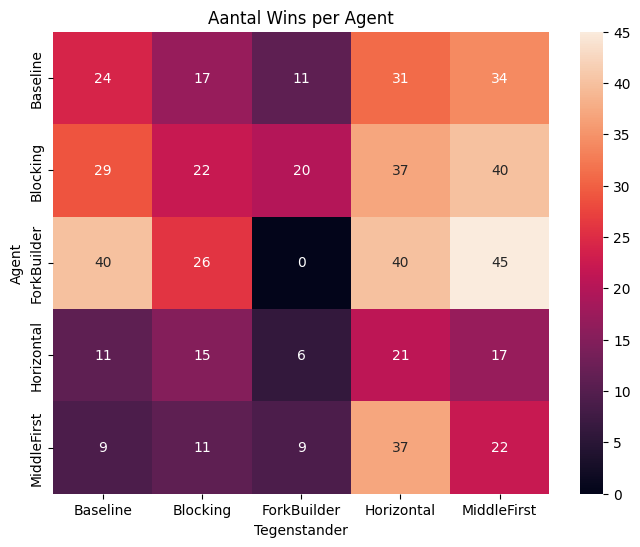

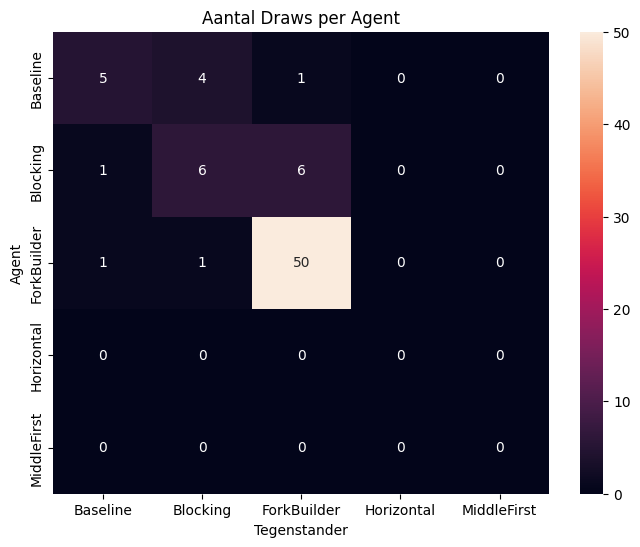

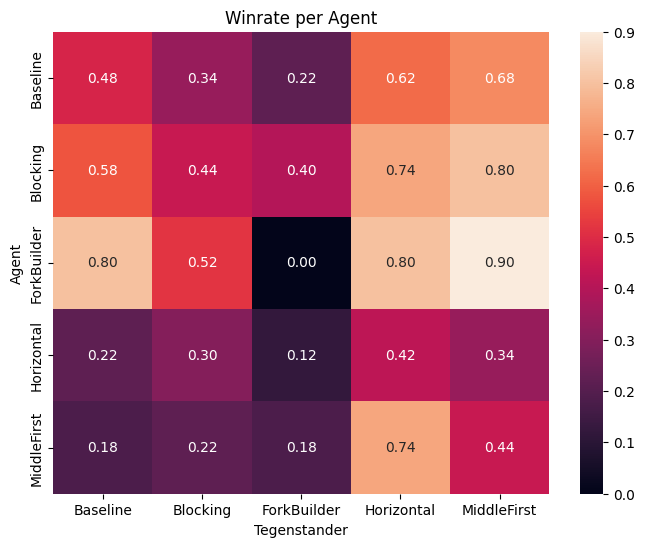

In [12]:
# 🔥 WINS
plt.figure(figsize=(8,6))
sns.heatmap(wins_matrix, annot=True, fmt=".0f",
            xticklabels=names, yticklabels=names)
plt.title("Aantal Wins per Agent")
plt.xlabel("Tegenstander")
plt.ylabel("Agent")
plt.show()


# 🔥 DRAWS
plt.figure(figsize=(8,6))
sns.heatmap(draws_matrix, annot=True, fmt=".0f",
            xticklabels=names, yticklabels=names)
plt.title("Aantal Draws per Agent")
plt.xlabel("Tegenstander")
plt.ylabel("Agent")
plt.show()


# 🔥 WINRATE
plt.figure(figsize=(8,6))
sns.heatmap(winrate_matrix, annot=True, fmt=".2f",
            xticklabels=names, yticklabels=names)
plt.title("Winrate per Agent")
plt.xlabel("Tegenstander")
plt.ylabel("Agent")
plt.show()